In [1]:
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split

In [2]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
from xgboost import XGBClassifier
 
from GTD_features import (DUMMY_SOURCES, FREQ_INPUTS, NUM_INPUTS,
                          build_features, unscale)

In [5]:
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
 
data = pd.read_csv("D:\MLCOE PROBATION TASKS\TASK 3\Data\gtd_model_ready.csv")
scaler = joblib.load("D:\MLCOE PROBATION TASKS\TASK 3\models\scaler.pkl")
print("Loaded Step 4 output:", data.shape)

Loaded Step 4 output: (181691, 135)


In [6]:
nkill_raw = unscale(scaler, "nkill", data["nkill"])
was_missing = unscale(scaler, "nkill_was_missing", data["nkill_was_missing"]) > 0.5
keep = ~was_missing
y = (nkill_raw[keep] > 0.5).astype(int)
print("Modelling rows:", int(keep.sum()), "| fatal share:", round(y.mean() * 100, 1), "%")

Modelling rows: 171378 | fatal share: 48.6 %


In [7]:
dummy_cols = sorted(c for c in data.columns
                    if any(c.startswith(s + "_") for s in DUMMY_SOURCES))
FEATURES = NUM_INPUTS + list(FREQ_INPUTS.values()) + dummy_cols
X = data.loc[keep, FEATURES].astype("float32")
print("Feature matrix:", X.shape)

Feature matrix: (171378, 63)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (137102, 63) | Test: (34276, 63)


**Insight**:

In [9]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, min_samples_leaf=3, n_jobs=-1, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8, tree_method="hist", eval_metric="logloss",
        n_jobs=-1, random_state=RANDOM_STATE),
}
 
fitted, rows, preds = {}, [], {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    secs = time.time() - t0
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    fitted[name], preds[name] = model, pred
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "Train time (s)": round(secs, 1),
    })
    print(f"{name}: done in {secs:.0f}s")

Random Forest: done in 5s
AdaBoost: done in 29s
XGBoost: done in 3s


**Insights**:

In [14]:
base_pred = np.full(len(y_test), int(y_train.mode()[0]))
rows.append({
    "Model": "Baseline (always majority class)",
    "Accuracy": accuracy_score(y_test, base_pred),
    "Precision": precision_score(y_test, base_pred, zero_division=0),
    "Recall": recall_score(y_test, base_pred),
    "F1": f1_score(y_test, base_pred),
    "ROC-AUC": 0.5,
    "Train time (s)": 0.0,
})
results = pd.DataFrame(rows).set_index("Model")
print(results.round(4).to_string())
results.round(4).to_csv("../Data/processed/model_comparison.csv")
 
best_name = results.drop(index="Baseline (always majority class)")["F1"].idxmax()
print("\nBest model by F1:", best_name)

                                  Accuracy  Precision  Recall      F1  ROC-AUC  Train time (s)
Model                                                                                         
Random Forest                       0.8077     0.7926  0.8181  0.8051   0.8912             5.2
AdaBoost                            0.7535     0.7487  0.7412  0.7449   0.8344            28.5
XGBoost                             0.8100     0.7928  0.8242  0.8082   0.8915             3.1
Baseline (always majority class)    0.5144     0.0000  0.0000  0.0000   0.5000             0.0
Baseline (always majority class)    0.5144     0.0000  0.0000  0.0000   0.5000             0.0

Best model by F1: XGBoost


**Insight**:

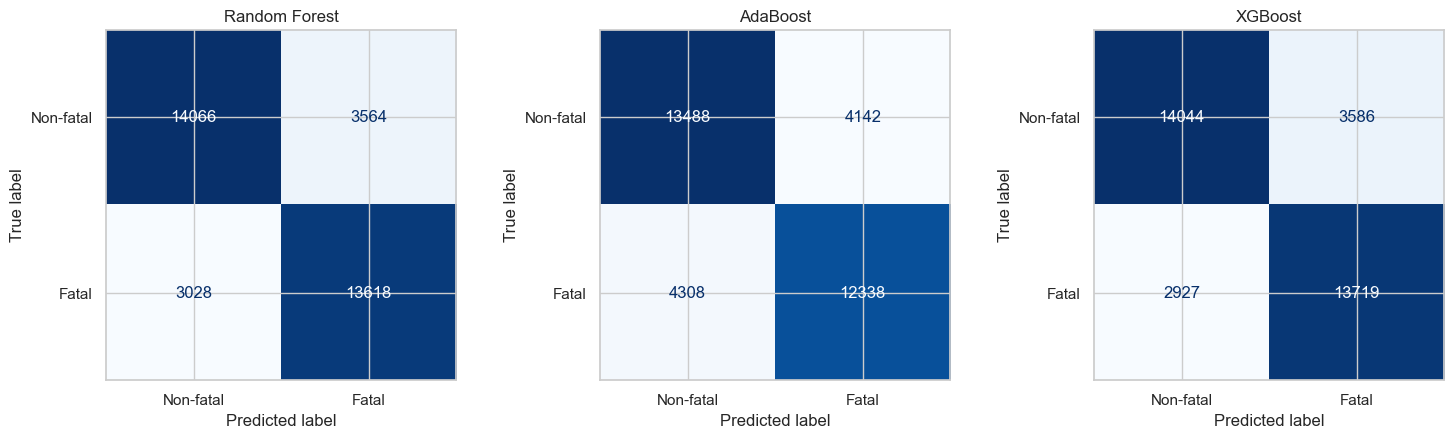

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, pred) in zip(axes, preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=["Non-fatal", "Fatal"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name)
plt.tight_layout()
plt.show()

**Insight**:

In [16]:
def source_of(col):
    for enc, raw in {v: k for k, v in FREQ_INPUTS.items()}.items():
        if col == enc:
            return raw
    for s in DUMMY_SOURCES:
        if col.startswith(s + "_"):
            return s
    return col
 
def aggregate(importances):
    out = {}
    for col, imp in zip(FEATURES, importances):
        out[source_of(col)] = out.get(source_of(col), 0.0) + float(imp)
    return pd.Series(out).sort_values()

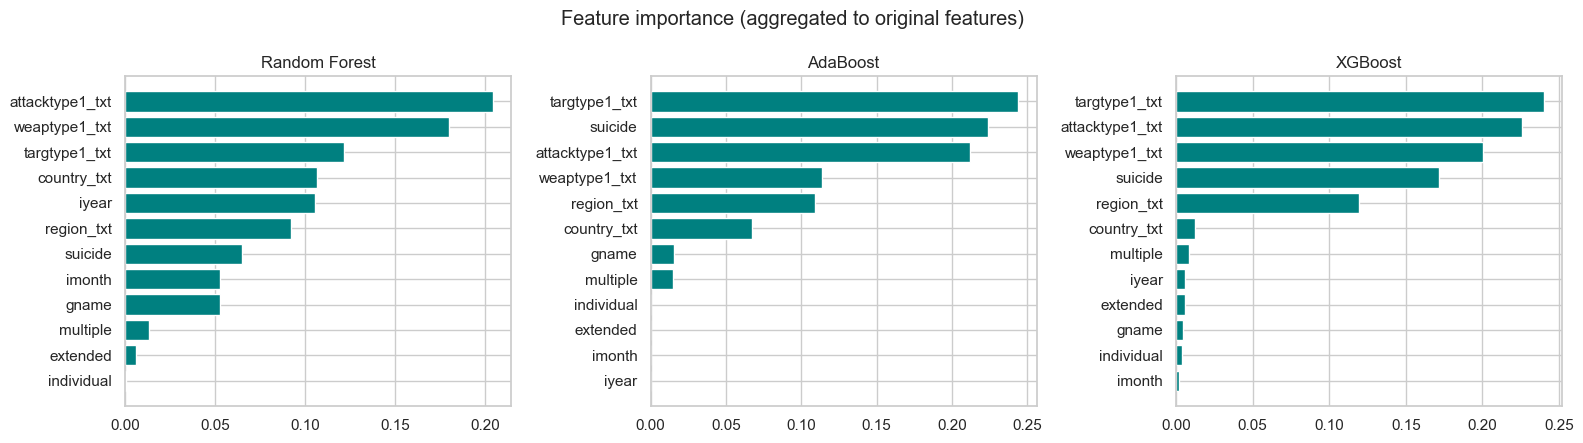


Random Forest — top 5:
attacktype1_txt    0.204
weaptype1_txt      0.180
targtype1_txt      0.122
country_txt        0.107
iyear              0.105

AdaBoost — top 5:
targtype1_txt      0.244
suicide            0.224
attacktype1_txt    0.212
weaptype1_txt      0.114
region_txt         0.109

XGBoost — top 5:
targtype1_txt      0.240
attacktype1_txt    0.226
weaptype1_txt      0.200
suicide            0.172
region_txt         0.119


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
importance_tables = {}
for ax, (name, model) in zip(axes, fitted.items()):
    imp = aggregate(model.feature_importances_)
    importance_tables[name] = imp.sort_values(ascending=False)
    ax.barh(imp.index, imp.values, color="teal")
    ax.set_title(name)
plt.suptitle("Feature importance (aggregated to original features)")
plt.tight_layout()
plt.show()
for name, imp in importance_tables.items():
    print(f"\n{name} — top 5:\n{imp.head(5).round(3).to_string()}")

**Insight**:

In [19]:
eda = pd.read_csv("D:\MLCOE PROBATION TASKS\TASK 3\Data\processed\globalterrorismdb_reduced_stage1.csv", encoding="latin-1",
                  low_memory=False,
                  usecols=["eventid", "region_txt", "country_txt", "attacktype1_txt",
                           "targtype1_txt", "weaptype1_txt", "gname"] + NUM_INPUTS)
assert (eda["eventid"].values == data["eventid"].values).all(), "row order differs from Step 4"

In [20]:
freq_maps = {c: eda[c].value_counts(normalize=True).to_dict() for c in FREQ_INPUTS}
freq_floor = {c: min(m.values()) for c, m in freq_maps.items()}
art = {"scaler": scaler, "freq_maps": freq_maps, "freq_floor": freq_floor,
       "feature_cols": FEATURES}

In [21]:
probe = eda.dropna(subset=NUM_INPUTS).sample(500, random_state=1)
rebuilt = build_features(probe, art)
stored = data.loc[probe.index, FEATURES].astype(float)
max_diff = float(np.abs(rebuilt.values - stored.values).max())
print("Max difference, rebuilt vs Step 4 features:", max_diff)
assert max_diff < 1e-6, "inference features do not match training features"

Max difference, rebuilt vs Step 4 features: 3.552713678800501e-15


In [24]:
best_model = fitted[best_name]
joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(art, "../models/preprocessor.pkl")
 
top_groups = [g for g, cnt in eda["gname"].value_counts().items() if cnt >= 300]
config = {
    "best_model": best_name,
    "options": {
        "region_txt": sorted(eda["region_txt"].unique()),
        "attacktype1_txt": sorted(eda["attacktype1_txt"].unique()),
        "targtype1_txt": sorted(eda["targtype1_txt"].unique()),
        "weaptype1_txt": sorted(eda["weaptype1_txt"].unique()),
        "gname": sorted(top_groups),
    },
    "region_to_countries": eda.groupby("region_txt")["country_txt"]
                              .apply(lambda s: sorted(s.unique())).to_dict(),
    "year_min": int(eda["iyear"].min()),
    "year_max": int(eda["iyear"].max()),
    "test_metrics": results.loc[best_name].round(4).to_dict(),
}
with open("../app_config.json", "w") as f:
    json.dump(config, f, indent=2)
 

In [27]:
m2 = joblib.load(r"D:\MLCOE PROBATION TASKS\TASK 3\models\best_model.pkl")
a2 = joblib.load(r"D:\MLCOE PROBATION TASKS\TASK 3\models\preprocessor.pkl")
via_raw = m2.predict_proba(build_features(probe, a2).astype("float32"))[:, 1]
via_step4 = best_model.predict_proba(stored.astype("float32"))[:, 1]
assert np.allclose(via_raw, via_step4), "raw-input path disagrees with Step 4 path"
print("Reload OK — raw-input predictions match Step 4 features exactly.")
print("First 5 P(fatal):", np.round(via_raw[:5], 3))

Reload OK — raw-input predictions match Step 4 features exactly.
First 5 P(fatal): [0.875 0.866 0.345 0.108 0.168]
